# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



# Problem Statement

This is a tree based reggression model using AWS S3 Sptotify.csv to predicit the popularity of a song before it is dropped onto the Spotify platform.  




## Target Popularity
Could be streams, followers, plays or views.




## Column sort

### y candidates (post-release outcomes)
1. Popularity
2.  Number of Times Charted
3.	Streams
4.  Highest Charting Position
5.  Weeks Charted
### X (pre-release predictors)
1.   Artist  drop this column wont get clean distribution
2.   Artist Followers  is a better predictor of popularity
3.   Genre
4.   Release Date
5.   Danceability
6.	Energy
7.	Loudness
8.	Speechiness
9. Acousticness
10.  Liveness
11.  Tempo
12.  Duration (ms)
13.  Valence
14.  Chord
### Drop (IDs, redundant, or otherwise unusable)
1. Index is row number
2. Song Name is unique
3. Song Id is unique
4. Week of Highest Charting


#### Calling data source
Amazonaws.com

In [1]:
# Set the URL
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

### Curl
1. x -amz request id file request
2. x request id 640TYSYJZ1RBH2PC
3. Date 15/July/2026
4. Last Mod 2023/11/04
5. Hash ID
6. Encrypted AES256
6. Content Len 738,124 BYTES
7. Amazon ServerS3


In [2]:
# Look at the headers
!curl -s -I {url}


HTTP/1.1 200 OK
x-amz-id-2: 8s5lxJ5//jb5uG7ThqqEmyj6GYqFUm12e4v2rpabGXSSJjYQKpCChgll0qlxahLM63qgUttOE3o=
x-amz-request-id: PVPJ7T44JVTKBB7Z
Date: Thu, 16 Jul 2026 05:02:36 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [3]:
# Download the file
!curl -s -O {url}


In [4]:
# Verify
!ls -la


total 740
drwxr-xr-x 1 root root   4096 Jul 16 00:30 .
drwxr-xr-x 1 root root   4096 Jul 16 00:27 ..
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 738124 Jul 16 05:02 Spotify.csv


### Column Headers
Total 23 Headers, first row of Spotify.csv
tr , '\n' remove comma create new line for each header
cat -n numbers the headers

In [5]:
# Look at the field names
!head -1 Spotify.csv | tr , '\n' | cat -n


     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


## IMPORT Libraries

In [6]:

# ─── All imports ──────────────────────────────────
import numpy as np
import pandas as pd
import ast
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
import threading, time, itertools

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

### Create Dataframe df

[5 rows x 23 columns]  with df.head

In [7]:

df = pd.read_csv('Spotify.csv')

# Quick inspection

print(df.head())



   Index  Highest Charting Position  Number of Times Charted  \
0      1                          1                        8   
1      2                          2                        3   
2      3                          1                       11   
3      4                          3                        5   
4      5                          5                        1   

  Week of Highest Charting                          Song Name     Streams  \
0   2021-07-23--2021-07-30                            Beggin'  48,633,449   
1   2021-07-23--2021-07-30          STAY (with Justin Bieber)  47,248,719   
2   2021-06-25--2021-07-02                           good 4 u  40,162,559   
3   2021-07-02--2021-07-09                         Bad Habits  37,799,456   
4   2021-07-23--2021-07-30  INDUSTRY BABY (feat. Jack Harlow)  33,948,454   

           Artist Artist Followers                 Song ID  \
0        Måneskin          3377762  3Wrjm47oTz2sjIgck11l5e   
1   The Kid LAROI          2

### Check Tail

Last five index entries 1552 to 1556


In [8]:
df.tail()

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F
1555,1556,199,1,2019-12-27--2020-01-03,Lover (Remix) [feat. Shawn Mendes],"4,595,450",Taylor Swift,42227614,3i9UVldZOE0aD0JnyfAZZ0,"['pop', 'post-teen pop']",...,0.448,0.603,-7.176,0.064,0.433,0.0862,205.272,221307,0.422,G


### Describe
Statistics of Spotify.csv

In [9]:

print(df.describe())

             Index  Highest Charting Position  Number of Times Charted
count  1556.000000                1556.000000              1556.000000
mean    778.500000                  87.744216                10.668380
std     449.322824                  58.147225                16.360546
min       1.000000                   1.000000                 1.000000
25%     389.750000                  37.000000                 1.000000
50%     778.500000                  80.000000                 4.000000
75%    1167.250000                 137.000000                12.000000
max    1556.000000                 200.000000               142.000000


### Class Panda.core.frame.DataFrame


1.   RangeIndex: 1556 entries, 0 to 1555
2.  Data columns (total 23 columns)



3.   dtypes: int64(3), object(20)

4.   memory usage: 279.7+ KB



In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

### Check for Nulls
No missing values

In [11]:
# Check for missing values
print(df.isnull().sum())



Index                        0
Highest Charting Position    0
Number of Times Charted      0
Week of Highest Charting     0
Song Name                    0
Streams                      0
Artist                       0
Artist Followers             0
Song ID                      0
Genre                        0
Release Date                 0
Weeks Charted                0
Popularity                   0
Danceability                 0
Energy                       0
Loudness                     0
Speechiness                  0
Acousticness                 0
Liveness                     0
Tempo                        0
Duration (ms)                0
Valence                      0
Chord                        0
dtype: int64


In [12]:
print(df.isnull().sum().sum())

0


### Looking at Numeric Columns  

Potential target columns:

 ['Index', 'Highest Charting Position', 'Number of Times Charted']

In [13]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Potential target columns:", numerical_cols)

Potential target columns: ['Index', 'Highest Charting Position', 'Number of Times Charted']


### Datatype Obj

Did not appear in numerical columns - will convert to int64 or float64 dtype.

In [14]:
print(df['Streams'].head(10))
print("\nDtype:", df['Streams'].dtype)

0    48,633,449
1    47,248,719
2    40,162,559
3    37,799,456
4    33,948,454
5    30,071,134
6    29,356,736
7    26,951,613
8    25,030,128
9    24,551,591
Name: Streams, dtype: object

Dtype: object


# Convert Streams
Streams converted to dtype float64 in case becomes feature X or predictor y.

In [15]:
# Strip commas, convert to ints
df['Streams'] = df['Streams'].str.replace(',', '', regex=False).astype(int)

# Verifying the commas are stripped from the dataset
print("Dtype after clean:", df['Streams'].dtype)  # Streams no missing streams 1556 non-null   object
print(df['Streams'].describe())                   # min 4.18 million streams, median 5.28 million streams, max is 48.64 streams,
                                                  # mean is greater 6.34 > than the median so data is right skewed

Dtype after clean: int64
count    1.556000e+03
mean     6.340219e+06
std      3.369479e+06
min      4.176083e+06
25%      4.915322e+06
50%      5.275748e+06
75%      6.455044e+06
max      4.863345e+07
Name: Streams, dtype: float64


### Checking Skew of Streams

Raw Stream values are positively skewed (5.9) - will log1p to reduce skewness

Log1p reduced skew (2.388).  Stabilizes RMSE accross the data. Log1p calculated so an artist with 500 million streams does not dominate the RMSE calculation and crowd out an artist who streams 5 million times. Both streaming values matter equally after tranforming transforming target y.

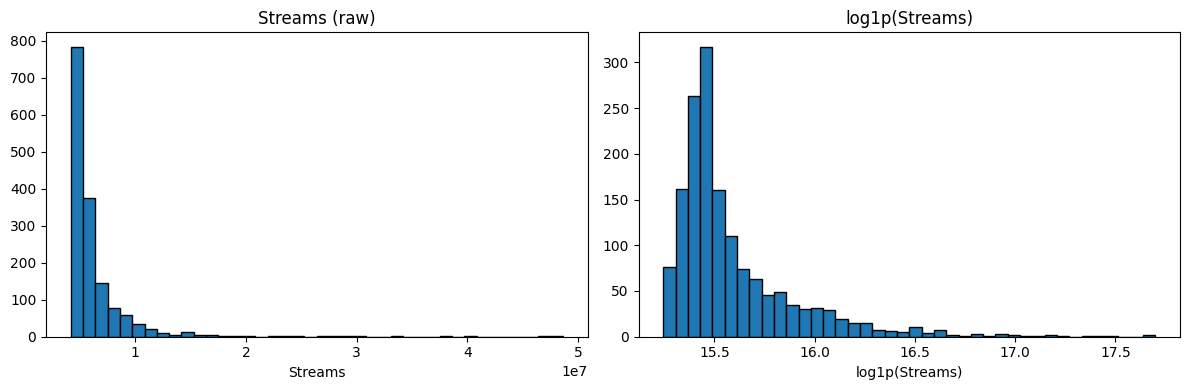

Skewness (raw):   5.915
Skewness (log1p): 2.388


In [16]:



fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw Streams
axes[0].hist(df['Streams'], bins=40, edgecolor='black')
axes[0].set_title('Streams (raw)')
axes[0].set_xlabel('Streams')

# log1p(Streams)
axes[1].hist(np.log1p(df['Streams']), bins=40, edgecolor='black')
axes[1].set_title('log1p(Streams)')
axes[1].set_xlabel('log1p(Streams)')

plt.tight_layout()
plt.show()

# Quantify skewness
from scipy.stats import skew
print(f"Skewness (raw):   {skew(df['Streams']):.3f}")
print(f"Skewness (log1p): {skew(np.log1p(df['Streams'])):.3f}")

### Number of Times Charted
Will not use 'Number of Times Charted' as y.  Significant diffrence in lister prefrence for artists.  

**Example:**

6iX9ine charted 20 times, had position 4 on the chart with 4.69 million  streams, and a 70% popularity score.

In contrast BED by Joel, Corry, RAYE, David Guetta charted 20 times. held position 42, streamed more than the position 4 at 7.38 million streams and 87.0 more popular.  

Dropped entirly to avoid leakage predicting new not yet released songs, X is information realted to songs that have been released - Streams, Popularity, Times Charted, Highest Charting Position, Weeks Charted, Week of Highest Charting.  

In [17]:
print(df['Number of Times Charted'].head(10))
print("\nDtype:", df['Number of Times Charted'].dtype)

0     8
1     3
2    11
3     5
4     1
5    18
6    16
7    10
8     8
9    10
Name: Number of Times Charted, dtype: int64

Dtype: int64


In [18]:
# Find pairs of songs that charted the same # of weeks
# but had different Highest Charting Position
same_weeks = df.groupby('Number of Times Charted').filter(
    lambda g: g['Highest Charting Position'].nunique() >= 2 and len(g) >= 5
)

# Pick a mid-range weeks value where we can see the contrast
target_weeks = 20   # try 10, 15, 20 — adjust based on what's in the data
subset = df[df['Number of Times Charted'] == target_weeks][
    ['Song Name', 'Artist', 'Number of Times Charted',
     'Highest Charting Position', 'Streams', 'Popularity']
].sort_values('Highest Charting Position')

print(f"Songs that charted exactly {target_weeks} weeks:")
print(subset.head(10).to_string(index=False))

Songs that charted exactly 20 weeks:
                                                  Song Name                         Artist  Number of Times Charted  Highest Charting Position  Streams Popularity
                                                      GOOBA                        6ix9ine                       20                          4  4690955         70
                                                     Savage            Megan Thee Stallion                       20                         16  4510218         75
                                          You should be sad                         Halsey                       20                         16  4761908         76
Agua (with J Balvin) - Music From "Sponge On The Run" Movie                          Tainy                       20                         19  5358940           
                                                   Suicidal                      YNW Melly                       20                         23  4320

### Stats on Times Charted


In [19]:
# Times Charted — quick diagnostic before ruling it out
print("Dtype:", df['Number of Times Charted'].dtype)
print(df['Number of Times Charted'].describe())
print(f"\nUnique values: {df['Number of Times Charted'].nunique()}")
print(f"Max value: {df['Number of Times Charted'].max()}")
print(f"Mode (most common): {df['Number of Times Charted'].mode().values}")

Dtype: int64
count    1556.000000
mean       10.668380
std        16.360546
min         1.000000
25%         1.000000
50%         4.000000
75%        12.000000
max       142.000000
Name: Number of Times Charted, dtype: float64

Unique values: 75
Max value: 142
Mode (most common): [1]


### Log1P on Number of Times Charted
The raw skew is 2.762 > log1p 0.671.  Log1p is more evenly distributed accross the range, model can distingush a pattern - might use 'Number of Times Charted'
one concern is that some songs charted for the same period as others but were less popular.

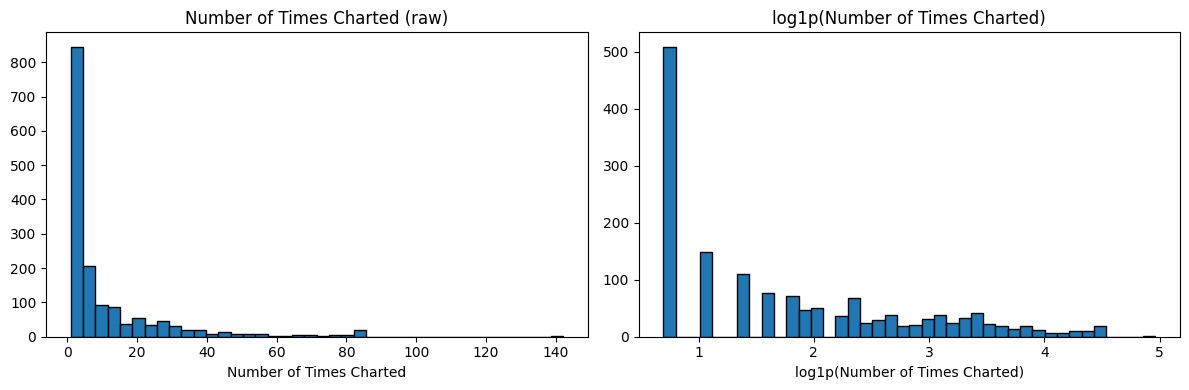

Skewness (raw):   2.762
Skewness (log1p): 0.671


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw Number of Times Charted
axes[0].hist(df['Number of Times Charted'], bins=40, edgecolor='black')
axes[0].set_title('Number of Times Charted (raw)')
axes[0].set_xlabel('Number of Times Charted')

# log1p(Number of Times Charted)
axes[1].hist(np.log1p(df['Number of Times Charted']), bins=40, edgecolor='black')
axes[1].set_title('log1p(Number of Times Charted)')
axes[1].set_xlabel('log1p(Number of Times Charted)')

plt.tight_layout()
plt.show()

# Quantify skewness
from scipy.stats import skew
print(f"Skewness (raw):   {skew(df['Number of Times Charted']):.3f}")
print(f"Skewness (log1p): {skew(np.log1p(df['Number of Times Charted'])):.3f}")

### Note: Weeks Charted date-to-int exploration

Exploring the 'Weeks Charted' date ranges are strings not date.types - dropping from y as target and X as predictors, looks to be related to TImes Charted. Post-release columns can be y. Only pre-release columns can be X.

In [21]:
print(df['Weeks Charted'].head(10))
print("\nDtype:", df['Weeks Charted'].dtype)

0    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
1    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
2    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
3    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
4                               2021-07-23--2021-07-30
5    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
6    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
7    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
8    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
9    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
Name: Weeks Charted, dtype: object

Dtype: object


### Popularity

May use these code cells

In [22]:
# Examine potential targets
potential_targets = ['Popularity'] + [col for col in df.columns
  if any(word in col.lower()
  for word in ['stream', 'view', 'play', 'rank', 'chart'])]

In [23]:
print(df['Popularity'].head(10))
print("\nDtype:", df['Popularity'].dtype)

0    100
1     99
2     99
3     98
4     96
5     97
6     94
7     95
8     96
9     95
Name: Popularity, dtype: object

Dtype: object


In [24]:
# DESCRIBE
print(df['Popularity'].describe())

count     1556
unique      70
top         75
freq        67
Name: Popularity, dtype: object


In [25]:
# What's non-numeric in Popularity?
non_numeric = df[pd.to_numeric(df['Popularity'], errors='coerce').isna()]
print(f"Rows with non-numeric Popularity: {len(non_numeric)}")
print(non_numeric['Popularity'].value_counts())

Rows with non-numeric Popularity: 11
Popularity
    11
Name: count, dtype: int64


In [26]:
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')
print(df['Popularity'].dtype, df['Popularity'].isna().sum(), "nulls")

float64 11 nulls


### Popularity
Popularity cannot be used as a y target, the output below shows some artists were more popular, streamed more and ranked lower on position. The skew is negative - left skewed, piling up towards 100 for popularity.

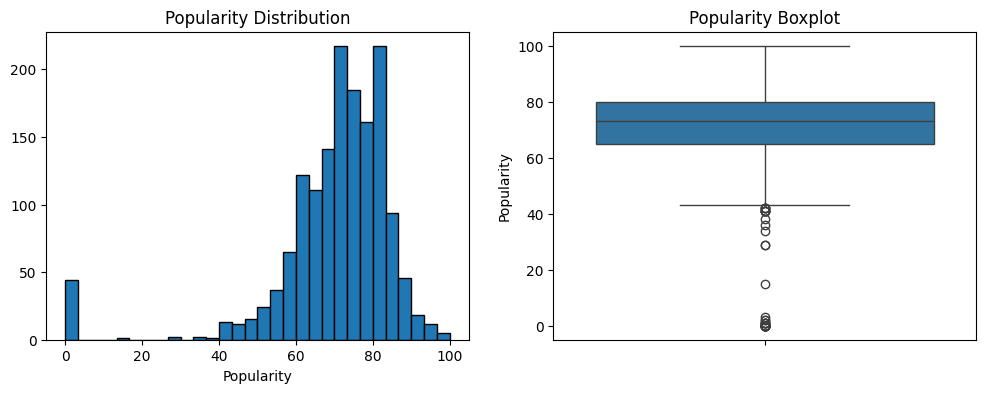

In [27]:
# Check distribution of 'Popularity'


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['Popularity'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity')

# Boxplot
sns.boxplot(y=df['Popularity'], ax=axes[1])
axes[1].set_title('Popularity Boxplot');



In [28]:
y = np.log1p(df['Streams'])
print(f"y (log1p Streams) — mean: {y.mean():.2f}, std: {y.std():.2f}")

y (log1p Streams) — mean: 15.60, std: 0.32


### Drop X COULUMNS

In [29]:


# 1. Drop y-side, ID, and text columns from df to form X
drop_cols = ['Index', 'Song Name', 'Song ID', 'Week of Highest Charting',
             'Weeks Charted', 'Artist', 'Highest Charting Position',
             'Number of Times Charted', 'Streams', 'Popularity']
X = df.drop(columns=drop_cols).copy()

# 2. Coerce audio columns to numeric (blanks become NaN)
audio_cols = ['Artist Followers', 'Danceability', 'Energy', 'Loudness',
              'Speechiness', 'Acousticness', 'Liveness', 'Tempo',
              'Duration (ms)', 'Valence']
for col in audio_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# 3. Drop the 11 fully-blank rows and align y
bad_rows_mask = X[audio_cols].isna().any(axis=1)
X = X[~bad_rows_mask].copy()
y = y[~bad_rows_mask].copy()

# 4. Release Date → release_year
X['Release Date'] = X['Release Date'].astype(str)
year_only_mask = X['Release Date'].str.match(r'^\d{4}$')
X.loc[year_only_mask, 'Release Date'] = X.loc[year_only_mask, 'Release Date'] + '-01-01'
X['release_year'] = pd.to_datetime(X['Release Date'], errors='coerce').dt.year

# Handle the 2 stragglers (year-month only, e.g. '1957-09')
still_null = X['release_year'].isna()
if still_null.any():
    raw_dates = df.loc[X[still_null].index, 'Release Date']
    X.loc[still_null, 'release_year'] = raw_dates.str.extract(r'^(\d{4})')[0].astype(float)

X = X.drop(columns=['Release Date'])

# 5. Genre → parse list, multi-hot top 15 + n_genres count
X['Genre_parsed'] = X['Genre'].apply(ast.literal_eval)
all_genres = [g for sublist in X['Genre_parsed'] for g in sublist]
genre_counts = Counter(all_genres)
top_genres = [g for g, _ in genre_counts.most_common(15)]
for g in top_genres:
    X[f'genre_{g.replace(" ", "_")}'] = X['Genre_parsed'].apply(lambda tags: int(g in tags))
X['n_genres'] = X['Genre_parsed'].apply(len)
X = X.drop(columns=['Genre', 'Genre_parsed'])

# 6. Chord → one-hot
chord_dummies = pd.get_dummies(X['Chord'], prefix='chord', dtype=int)
X = pd.concat([X.drop(columns=['Chord']), chord_dummies], axis=1)

# 7. Confirm
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Nulls in X: {X.isna().sum().sum()}")

X shape: (1545, 39)
y shape: (1545,)
Nulls in X: 0


## Train/test split



In [30]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (1236, 39), y_train: (1236,)
X_test:  (309, 39), y_test:  (309,)


In [31]:

# Dummy: always predicts the mean of y_train
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))

print(f"Dummy RMSE (log1p Streams units): {rmse_dummy:.4f}")

Dummy RMSE (log1p Streams units): 0.2914


### Random Forest

In [32]:

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Dummy RMSE:         0.2914")
print(f"Improvement:        {(1 - rmse_rf/0.2914)*100:.1f}%")

Random Forest RMSE: 0.2883
Dummy RMSE:         0.2914
Improvement:        1.1%


In [33]:


# Feature importances from the RF we just trained
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))
print(f"\nTop 5 features account for {importances.head(5).sum()*100:.1f}% of importance")

Artist Followers    0.138403
release_year        0.098308
Acousticness        0.083184
Tempo               0.082166
Liveness            0.080588
Loudness            0.078031
Duration (ms)       0.070747
Valence             0.067156
Speechiness         0.059934
Energy              0.055823
Danceability        0.046333
n_genres            0.016165
chord_G#/Ab         0.011582
chord_D#/Eb         0.008543
genre_reggaeton     0.008467
dtype: float64

Top 5 features account for 48.3% of importance


In [34]:
y_pred_train = rf.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE:  {rmse_rf:.4f}")
print(f"Ratio (train/test): {rmse_train/rmse_rf:.3f}")

Train RMSE: 0.1178
Test RMSE:  0.2883
Ratio (train/test): 0.409


### Tune the Tree
hyperparameters

In [35]:


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5]
}



In [36]:


dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

rmse_dt_train = np.sqrt(mean_squared_error(y_train, dt.predict(X_train)))
rmse_dt_test  = np.sqrt(mean_squared_error(y_test,  dt.predict(X_test)))

print(f"Decision Tree — Train RMSE: {rmse_dt_train:.4f}")
print(f"Decision Tree — Test RMSE:  {rmse_dt_test:.4f}")
print(f"Dummy Test RMSE: 0.2914")
print(f"RF Test RMSE:    0.2883")

Decision Tree — Train RMSE: 0.0291
Decision Tree — Test RMSE:  0.3988
Dummy Test RMSE: 0.2914
RF Test RMSE:    0.2883


In [37]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # sklearn maximizes, so uses negative
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Best CV RMSE:  {-rf_grid.best_score_:.4f}")
print(f"Best params:   {rf_grid.best_params_}")

# Evaluate the tuned model on the held-out test set
best_rf = rf_grid.best_estimator_
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))
rmse_rf_tuned_test  = np.sqrt(mean_squared_error(y_test,  best_rf.predict(X_test)))
print(f"Tuned RF — Train RMSE: {rmse_rf_tuned_train:.4f}")
print(f"Tuned RF — Test RMSE:  {rmse_rf_tuned_test:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best CV RMSE:  0.2961
Best params:   {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Tuned RF — Train RMSE: 0.2126
Tuned RF — Test RMSE:  0.2791


In [38]:


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,       # per-fold heartbeat
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(f"\nBest CV RMSE:  {-rf_grid.best_score_:.4f}")
print(f"Best params:   {rf_grid.best_params_}")

best_rf = rf_grid.best_estimator_
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))
rmse_rf_tuned_test  = np.sqrt(mean_squared_error(y_test,  best_rf.predict(X_test)))
print(f"Tuned RF — Train RMSE: {rmse_rf_tuned_train:.4f}")
print(f"Tuned RF — Test RMSE:  {rmse_rf_tuned_test:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best CV RMSE:  0.2961
Best params:   {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Tuned RF — Train RMSE: 0.2126
Tuned RF — Test RMSE:  0.2791


In [39]:


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5]
}

# Heartbeat thread — prints a dot every 5 seconds until we tell it to stop
stop_flag = threading.Event()
def heartbeat():
    spinner = itertools.cycle(['|', '/', '-', '\\'])
    start = time.time()
    while not stop_flag.is_set():
        elapsed = int(time.time() - start)
        print(f"\r{next(spinner)} running... {elapsed}s elapsed", end='', flush=True)
        time.sleep(1)

hb = threading.Thread(target=heartbeat)
hb.start()

try:
    rf_grid = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid=param_grid,
        scoring='neg_root_mean_squared_error',
        cv=5,
        verbose=0,     # turn off sklearn chatter so heartbeat is clean
        n_jobs=-1
    )
    rf_grid.fit(X_train, y_train)
finally:
    stop_flag.set()
    hb.join()
    print()   # newline after heartbeat stops

print(f"Best CV RMSE:  {-rf_grid.best_score_:.4f}")
print(f"Best params:   {rf_grid.best_params_}")

best_rf = rf_grid.best_estimator_
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))
rmse_rf_tuned_test  = np.sqrt(mean_squared_error(y_test,  best_rf.predict(X_test)))
print(f"Tuned RF — Train RMSE: {rmse_rf_tuned_train:.4f}")
print(f"Tuned RF — Test RMSE:  {rmse_rf_tuned_test:.4f}")

| running... 172s elapsed
Best CV RMSE:  0.2961
Best params:   {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Tuned RF — Train RMSE: 0.2126
Tuned RF — Test RMSE:  0.2791


In [40]:


gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

rmse_gb_train = np.sqrt(mean_squared_error(y_train, gb.predict(X_train)))
rmse_gb_test  = np.sqrt(mean_squared_error(y_test,  gb.predict(X_test)))

print(f"Gradient Boosting default — Train RMSE: {rmse_gb_train:.4f}")
print(f"Gradient Boosting default — Test RMSE:  {rmse_gb_test:.4f}")
print(f"\nComparison:")
print(f"  Dummy:              0.2914")
print(f"  RF tuned:           0.2791")
print(f"  Gradient Boosting:  {rmse_gb_test:.4f}")

Gradient Boosting default — Train RMSE: 0.2124
Gradient Boosting default — Test RMSE:  0.2820

Comparison:
  Dummy:              0.2914
  RF tuned:           0.2791
  Gradient Boosting:  0.2820


In [41]:


param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 5, 10]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gb,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(f"\nBest CV RMSE:  {-gb_grid.best_score_:.4f}")
print(f"Best params:   {gb_grid.best_params_}")

best_gb = gb_grid.best_estimator_
rmse_gb_tuned_train = np.sqrt(mean_squared_error(y_train, best_gb.predict(X_train)))
rmse_gb_tuned_test  = np.sqrt(mean_squared_error(y_test,  best_gb.predict(X_test)))
print(f"Tuned GB — Train RMSE: {rmse_gb_tuned_train:.4f}")
print(f"Tuned GB — Test RMSE:  {rmse_gb_tuned_test:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV RMSE:  0.2997
Best params:   {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 100}
Tuned GB — Train RMSE: 0.2547
Tuned GB — Test RMSE:  0.2787


In [42]:

importances = pd.Series(best_gb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))
print(f"\nTop 5 features account for {importances.head(5).sum()*100:.1f}% of importance")

release_year        0.223573
Artist Followers    0.195283
Loudness            0.112922
Liveness            0.088676
Valence             0.069711
Speechiness         0.064302
Acousticness        0.061212
Tempo               0.047108
Duration (ms)       0.045014
Danceability        0.026071
genre_reggaeton     0.014389
chord_D#/Eb         0.013201
genre_hip_hop       0.012574
chord_D             0.007413
n_genres            0.005222
dtype: float64

Top 5 features account for 69.0% of importance


In [43]:


cv_scores = cross_val_score(
    best_gb, X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv=5
)
cv_rmse = -cv_scores
print(f"5-fold CV RMSE per fold: {cv_rmse.round(4)}")
print(f"Mean CV RMSE: {cv_rmse.mean():.4f}")
print(f"Std CV RMSE:  {cv_rmse.std():.4f}")

5-fold CV RMSE per fold: [0.2716 0.3327 0.2899 0.3301 0.2741]
Mean CV RMSE: 0.2997
Std CV RMSE:  0.0267


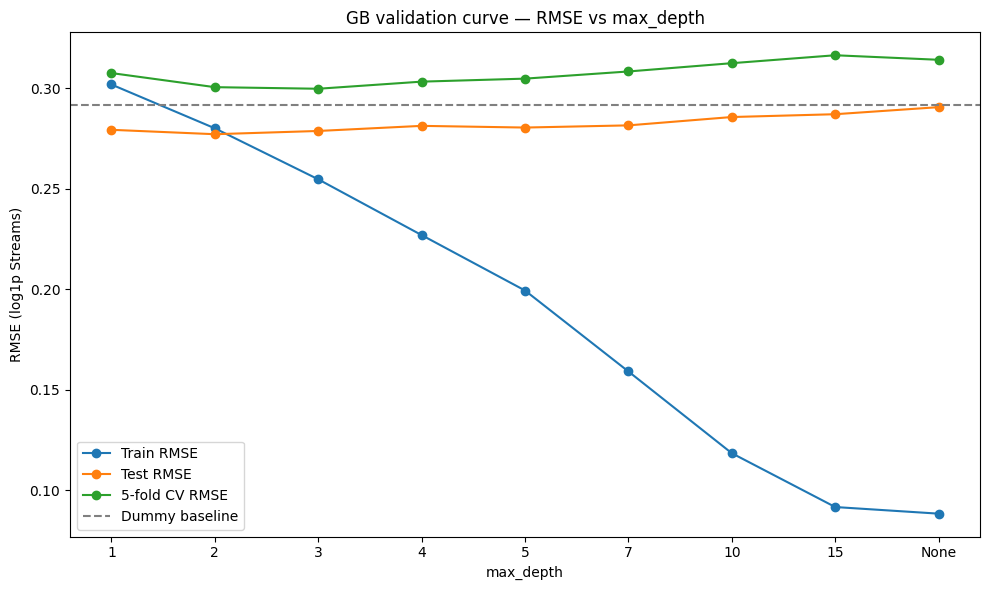

In [44]:


depths = [1, 2, 3, 4, 5, 7, 10, 15, None]
train_rmses = []
test_rmses  = []
cv_rmses    = []

for d in depths:
    gb_d = GradientBoostingRegressor(
        learning_rate=0.05,
        n_estimators=100,
        min_samples_leaf=10,
        max_depth=d,
        random_state=42
    )
    gb_d.fit(X_train, y_train)
    train_rmses.append(np.sqrt(mean_squared_error(y_train, gb_d.predict(X_train))))
    test_rmses.append(np.sqrt(mean_squared_error(y_test,  gb_d.predict(X_test))))
    cv = cross_val_score(gb_d, X_train, y_train,
                         scoring='neg_root_mean_squared_error', cv=5)
    cv_rmses.append(-cv.mean())

# Replace None with a plot-friendly value for the x-axis
depth_labels = [str(d) if d is not None else 'None' for d in depths]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depth_labels, train_rmses, marker='o', label='Train RMSE')
ax.plot(depth_labels, test_rmses,  marker='o', label='Test RMSE')
ax.plot(depth_labels, cv_rmses,    marker='o', label='5-fold CV RMSE')
ax.axhline(0.2914, color='gray', linestyle='--', label='Dummy baseline')
ax.set_xlabel('max_depth')
ax.set_ylabel('RMSE (log1p Streams)')
ax.set_title('GB validation curve — RMSE vs max_depth')
ax.legend()
plt.tight_layout()
plt.show()

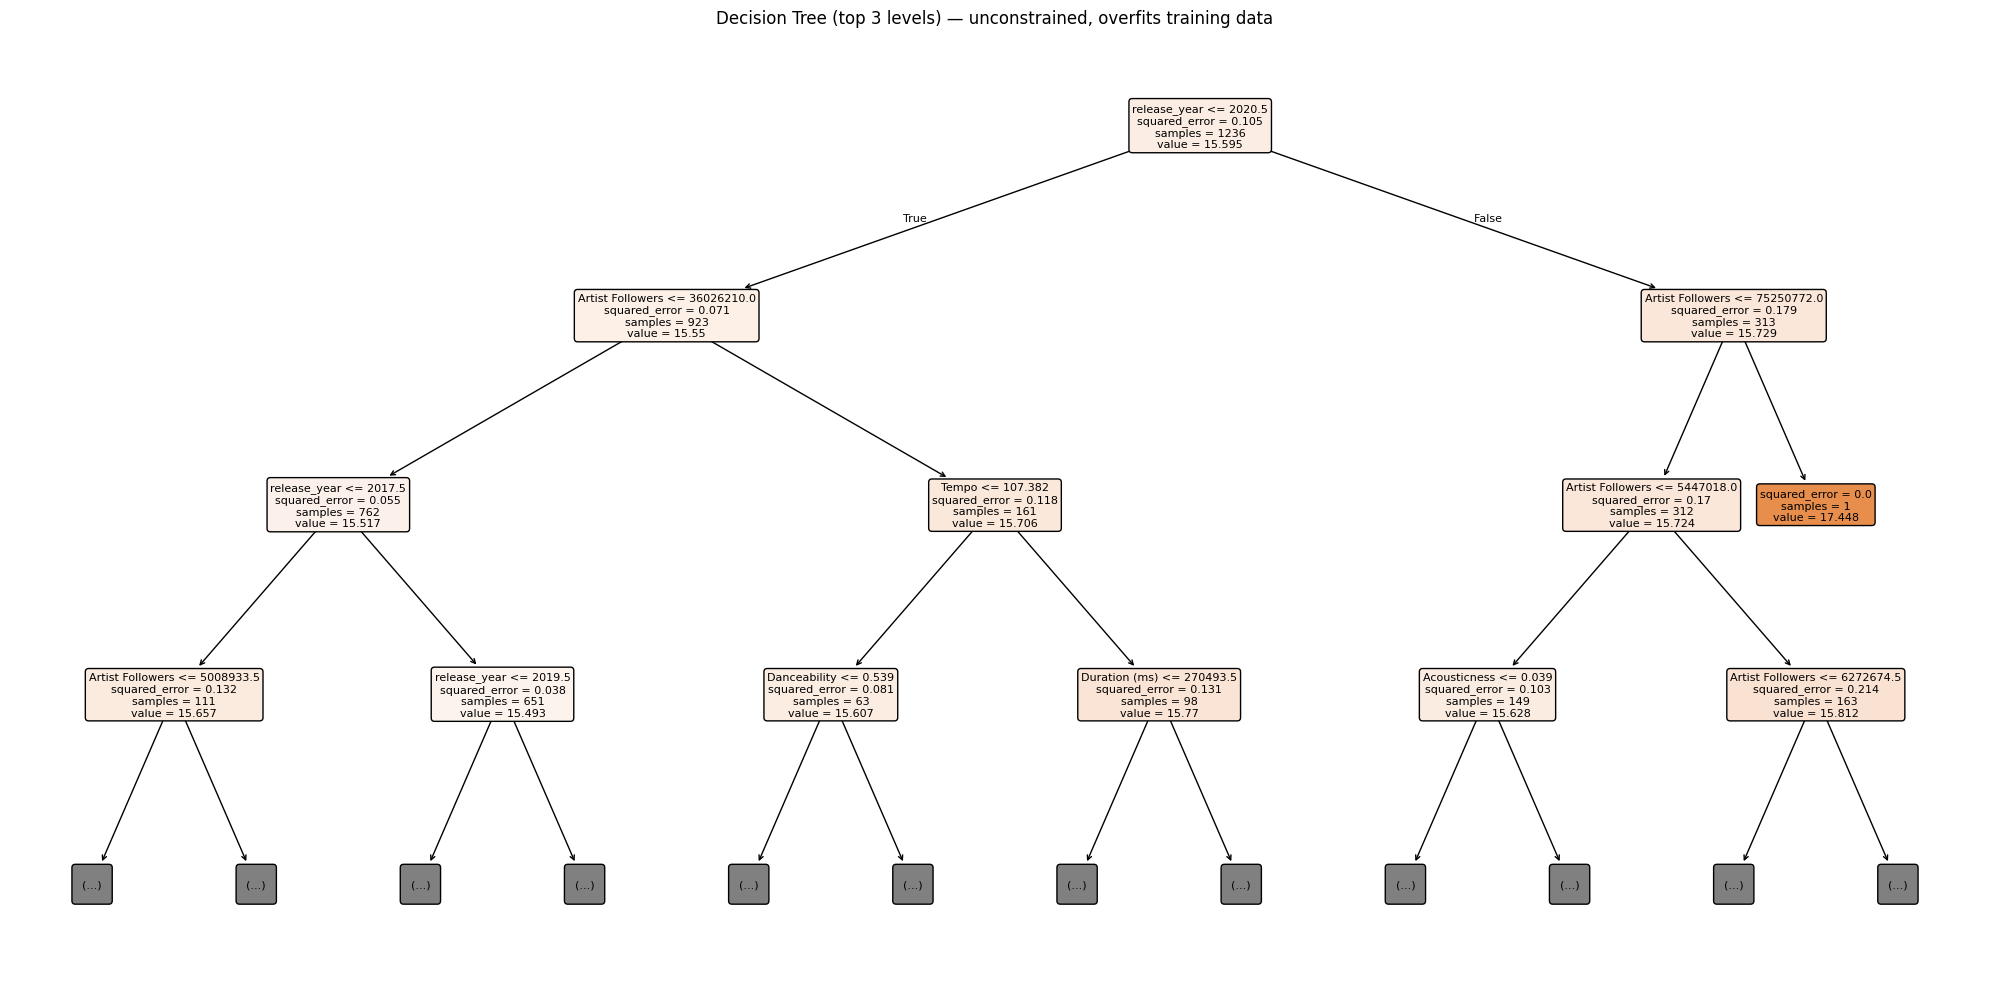

In [45]:


fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt,                          # the unconstrained Decision Tree from earlier
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=3,                 # only show top 3 levels — full tree is unreadable
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree (top 3 levels) — unconstrained, overfits training data')
plt.tight_layout()
plt.show()

Constrained DT — Train RMSE: 0.2722
Constrained DT — Test RMSE:  0.2949


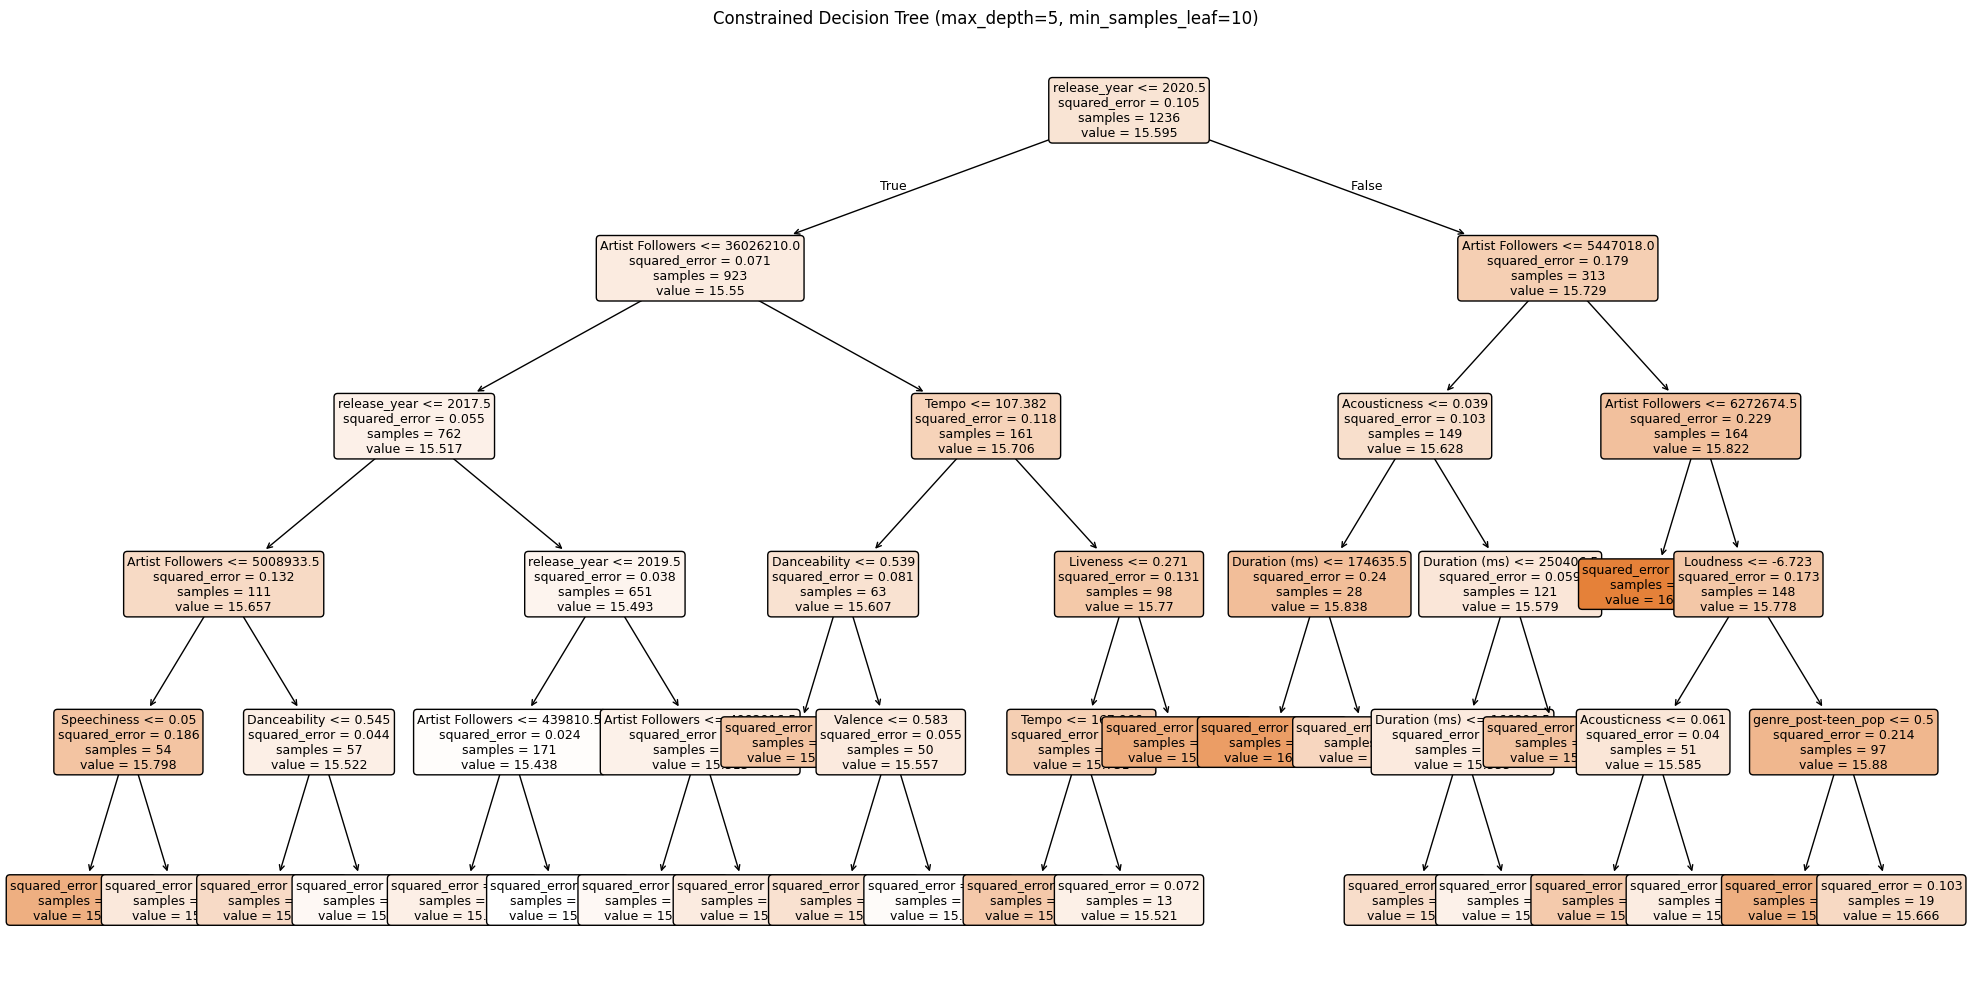

In [46]:


# A constrained single tree, matching the discipline of the ensemble models
dt_constrained = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
dt_constrained.fit(X_train, y_train)

rmse_dtc_train = np.sqrt(mean_squared_error(y_train, dt_constrained.predict(X_train)))
rmse_dtc_test  = np.sqrt(mean_squared_error(y_test,  dt_constrained.predict(X_test)))
print(f"Constrained DT — Train RMSE: {rmse_dtc_train:.4f}")
print(f"Constrained DT — Test RMSE:  {rmse_dtc_test:.4f}")

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_constrained,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Constrained Decision Tree (max_depth=5, min_samples_leaf=10)')
plt.tight_layout()
plt.show()